<a href="https://colab.research.google.com/github/mary1363/Knn-Regression-housing-price-prediction/blob/main/Copy_of_Count_People_CV_Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Install packages

In [ ]:
# Computer Vision & Detection
!pip install opencv-python       # Reading & processing images/frames
!pip install ultralytics         # YOLOv8 for person detection

# Tracking
!pip install deep-sort-realtime  # Person tracking & unique ID assignment

# Data Analysis & Time Series
!pip install pandas              # Data tables & DataFrame management
!pip install numpy               # Numerical computations & arrays
!pip install matplotlib          # Plotting images & charts
!pip install seaborn             # Advanced statistical plots

# Time Serires & Forcasting
!pip install statsmodels         # Statistical models (e.g., ARIMA)
!pip install prophet             # Forcasting people counts over time

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 62.0 MB/s eta 0:00:00


### Import basic libraries

In [12]:
import os
import cv2                      # Image/frame reading and processing
import numpy as np              # Arrays & numerical operations
import pandas as pd             # DataFrames & table operations
import matplotlib.pyplot as plt # plotting
import seaborn as sns           # Statistical plots
import scipy.io as sio          # Reading MATLAB

In [11]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Verify Videos & Ground Truth(RGB + Depth)

In [ ]:
# Base paths
video_base = '/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/VIDEOS'
gt_path = '/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/GROUND TRUTH'

# Recursively find all .mkv videos
all_videos = []
for root, dirs, files in os.walk(video_base):
    for f in files:
        if f.endswith('.mkv'):
            all_videos.append(os.path.join(root, f))

# Separate RGB and Depth videos
rgb_videos = [v for v in all_videos if '/RGB/' in v.replace("\\","/")]
depth_videos = [v for v in all_videos if '/DEPTH/' in v.replace("\\","/")]

print("Total videos found:", len(all_videos))
print("RGB videos:", len(rgb_videos))
print("Depth videos:", len(depth_videos))
print("Sample RGB videos:", rgb_videos[:3])
print("Sample Depth videos:", depth_videos[:3])

# Verify each video has a matching ground truth
gt_files = [f for f in os.listdir(gt_path) if f.endswith('.xgtf')]
missing_gt = []
for video_path in all_videos:
    video_name = os.path.basename(video_path)
    gt_name = video_name.replace('.mkv', '.xgtf')
    if gt_name not in gt_files:
        missing_gt.append(video_name)

if missing_gt:
    print("Videos missing ground truth:", missing_gt)
else:
    print("All videos have corresponding ground truth files.")

Total videos found: 34
RGB videos: 17
Depth videos: 17
Sample RGB videos: ['/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/VIDEOS/RGB/C_O_S_4.mkv', '/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/VIDEOS/RGB/C_O_S_3.mkv', '/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/VIDEOS/RGB/C_O_S_2.mkv']
Sample Depth videos: ['/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/VIDEOS/DEPTH/D_O_S_4.mkv', '/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/VIDEOS/DEPTH/D_O_S_2.mkv', '/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/VIDEOS/DEPTH/D_O_S_3.mkv']
All videos have corresponding ground truth files.


**MIVIA People Counting Dataset**

 – Short Summary

 • Includes 34 videos → 17 RGB (color) + 17 Depth (distance map) recorded from an overhead camera (640×480, 30 FPS).

 • Contains indoor/outdoor scenes with single and group crossings.

 • RGB videos: used for main person detection.

 • Depth videos: grayscale distance images, helpful in crowded or low-light situations.

 • Each video has a matching .xgtf Ground Truth file describing:

 • the frame of crossing /
 • the direction (L→R, R→L, T→B, B→T) /
 • the crossing configuration

 • Ground Truth does not include bounding boxes → YOLOv8 must generate them.


### Convert RGB & Depth Videos => Frames

In [ ]:
# Output folders for frames
frame_base = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames'
rgb_frame_folder = os.path.join(frame_base, 'RGB')
depth_frame_folder = os.path.join(frame_base, 'DEPTH')
os.makedirs(rgb_frame_folder, exist_ok=True)
os.makedirs(depth_frame_folder, exist_ok=True)

# Function to convert videos to frames
def video_to_frames(video_list, output_folder):
    for video_path in video_list:
        video_name = os.path.basename(video_path)[:-4]  # remove .mkv
        cap = cv2.VideoCapture(video_path)
        count = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame_name = f"{video_name}_frame_{count:05d}.jpg"
            cv2.imwrite(os.path.join(output_folder, frame_name), frame)
            count += 1
        cap.release()
        print(f"Converted {video_name} → {count} frames in {output_folder}")

# Convert RGB videos
print("Converting RGB videos...")
video_to_frames(rgb_videos, rgb_frame_folder)

# Convert Depth videos
print("Converting Depth videos...")
video_to_frames(depth_videos, depth_frame_folder)

Converting RGB videos...
Converted C_O_S_4 → 4858 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_O_S_3 → 4451 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_O_S_2 → 4666 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_O_S_1 → 4753 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_O_G_5 → 4398 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_O_G_4 → 4898 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_O_G_3 → 5879 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_O_G_2 → 4379 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_I_S_5 → 1845 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_O_G_1 → 4

- This cell loads all RGB and Depth videos and converts them into image frames.
- Extracted frames will be saved under /frames/RGB and /frames/DEPTH for further processing.
- These frames will later be used for YOLOv8 person detection and bounding-box generation.

### Model Loading with YOLO

In [3]:
# Install Ultralytics YOLOv8
!pip install ultralytics --quiet

from ultralytics import YOLO
import torch

# Load pretrained YOLOv8 model (nano = fastest)
model = YOLO('yolov8n.pt')

print("YOLOv8 loaded successfully!")
print("Torch device:", "CUDA (GPU)" if torch.cuda.is_available() else "CPU")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 loaded successfully!
Torch device: CPU


#### YOLOV8 Inference on Sample Frames

In [ ]:
# Select Sample Frames for Display
rgb_frame_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB'

# List of sample frames known to have people
sample_frames = [
    'C_I_G_1_frame_00222.jpg',  # frame with people
    'C_I_S_3_frame_00123.jpg',
    'C_I_S_3_frame_00108.jpg'
]


0: 480x640 1 person, 75.8ms
Speed: 7.1ms preprocess, 75.8ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)


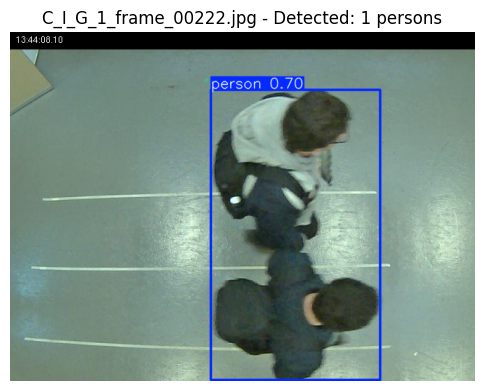


0: 480x640 1 dog, 1 snowboard, 7.3ms
Speed: 2.6ms preprocess, 7.3ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)


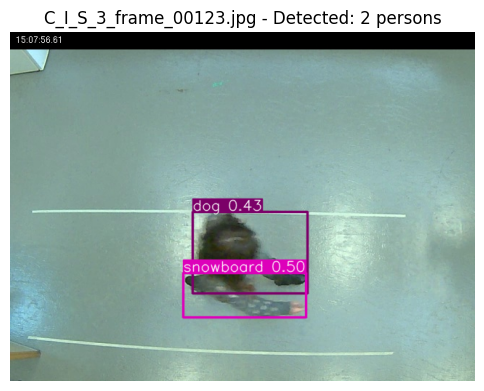


0: 480x640 2 persons, 12.0ms
Speed: 1.9ms preprocess, 12.0ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)


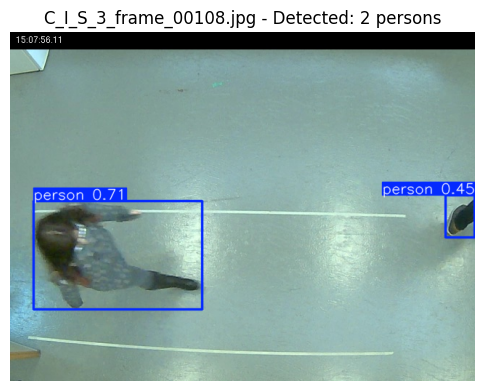

In [ ]:
# Run YOLOv8 Inference on Sample Frames

for frame_file in sample_frames:
    frame_path = os.path.join(rgb_frame_folder, frame_file)

    # Read the frame
    img = cv2.imread(frame_path)

    # Run YOLO inference
    results = model(img)

    # Annotate frame with bounding boxes
    annotated_img = results[0].plot()

    # Display annotated frame
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.title(f"{frame_file} - Detected: {len(results[0].boxes.xyxy)} persons")
    plt.axis('off')
    plt.show()

**YOLO**
- Run inference on a few sample frames.
- Visually inspect bounding boxes and confirm detection quality.
- The model predicts humans in typical scenes.

Some detections were imperfect (e.g., person merged as one, person detected as dag or snowboard).  
This is expected because raw detections are noisy.  
Tracking + filtering in the next steps will stabilize these detections.

#### Generate bounding box for RGB Frames

This cell runs the YOLOv8 model on every frame in the dataset and saves the detected bounding boxes into a CSV file.  
Each row in the CSV represents a single detection and includes:

- frame: filename of the frame  
- bbox_id: index of the detected box in that frame  
- x1, y1, x2, y2: bounding box coordinates  
- confidence: YOLO confidence score  
- class_id: predicted class (0 = person)


#### RGB Frames Processing

In [ ]:
# Create Results Folder

# This folder will store YOLO bounding box CSV files for RGB frames
results_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results'
os.makedirs(results_folder, exist_ok=True)

# Path to CSV for bounding boxes
output_csv_rgb = os.path.join(results_folder, 'yolo_detections_rgb.csv')
print("✅ Results folder ready:", results_folder)

✅ Results folder ready: /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results


#### Select 10% Consecutive RGB Frames from Middle

In [ ]:
# Sample 10% Consecutive RGB Frames from Middle

rgb_frame_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB'

# List all RGB frames and sort
all_frames = sorted([f for f in os.listdir(rgb_frame_folder) if f.endswith('.jpg')])

# Calculate 10% sample size
total_frames = len(all_frames)
sample_size = total_frames // 10

# Start from the middle
start_index = total_frames // 2
end_index = start_index + sample_size
sample_frames = all_frames[start_index:end_index]

print(f"Total RGB frames: {total_frames}")
print(f"Sample frames selected (10% consecutive from middle): {len(sample_frames)}")
print("First 5 sample frames:", sample_frames[:5])

Total RGB frames: 72951
Sample frames selected (10% consecutive from middle): 7295
First 5 sample frames: ['C_O_G_2_frame_01806.jpg', 'C_O_G_2_frame_01807.jpg', 'C_O_G_2_frame_01808.jpg', 'C_O_G_2_frame_01809.jpg', 'C_O_G_2_frame_01810.jpg']


Using consecutive frames from middle ensures smooth tracking and avoids skipping paths.

#### YOLOv8 Inference on RGB Sample Frames

In [ ]:
# Run YOLOv8 on Sample RGB Frames

# Extract bounding boxes and save to DataFrame
import cv2
import pandas as pd
from ultralytics import YOLO

# Load YOLOv8 model (already downloaded)
model = YOLO('yolov8n.pt')

# Prepare DataFrame to store bounding boxes
columns = ['frame', 'bbox_id', 'x1', 'y1', 'x2', 'y2', 'confidence', 'class_id']
df_rgb = pd.DataFrame(columns=columns)

# Process each sampled frame
for idx, frame_file in enumerate(sample_frames):
    frame_path = os.path.join(rgb_frame_folder, frame_file)
    img = cv2.imread(frame_path)

    # YOLO inference
    results = model(img, verbose=False)

    # Extract bounding boxes
    for b_id, box in enumerate(results[0].boxes.xyxy):
        x1, y1, x2, y2 = box.tolist()
        conf = results[0].boxes.conf[b_id].item()
        cls = int(results[0].boxes.cls[b_id].item())
        df_rgb.loc[len(df_rgb)] = [frame_file, b_id, x1, y1, x2, y2, conf, cls]

    # Status update every 50 frames
    if idx % 50 == 0:
        print(f"Processed {idx}/{len(sample_frames)} frames...")

# Save CSV
df_rgb.to_csv(output_csv_rgb, index=False)
print("\n✅ Done! Bounding box CSV saved at:")
print(output_csv_rgb)

Processed 0/7295 frames...
Processed 50/7295 frames...
Processed 100/7295 frames...
Processed 150/7295 frames...
Processed 200/7295 frames...
Processed 250/7295 frames...
Processed 300/7295 frames...
Processed 350/7295 frames...
Processed 400/7295 frames...
Processed 450/7295 frames...
Processed 500/7295 frames...
Processed 550/7295 frames...
Processed 600/7295 frames...
Processed 650/7295 frames...
Processed 700/7295 frames...
Processed 750/7295 frames...
Processed 800/7295 frames...
Processed 850/7295 frames...
Processed 900/7295 frames...
Processed 950/7295 frames...
Processed 1000/7295 frames...
Processed 1050/7295 frames...
Processed 1100/7295 frames...
Processed 1150/7295 frames...
Processed 1200/7295 frames...
Processed 1250/7295 frames...
Processed 1300/7295 frames...
Processed 1350/7295 frames...
Processed 1400/7295 frames...
Processed 1450/7295 frames...
Processed 1500/7295 frames...
Processed 1550/7295 frames...
Processed 1600/7295 frames...
Processed 1650/7295 frames...
Pro

#### Batch-wise YOLO Inference for Sample RGB Frames

- We process the sample 10% consecutive RGB frames in batches of 50 to avoid memory issues.
- YOLOv8 runs on each frame, generating bounding boxes, confidence scores, and class IDs.
- Results are stored in a DataFrame and finally saved as a CSV in results_folder.

In [ ]:
# Batch-wise YOLO Inference on Sample RGB Frames

# Save bounding boxes to CSV for tracking
import cv2
import pandas as pd
import os
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO('yolov8n.pt')

# Results folder
results_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results'
os.makedirs(results_folder, exist_ok=True)

# Prepare DataFrame for bounding boxes
columns = ['frame', 'bbox_id', 'x1', 'y1', 'x2', 'y2', 'confidence', 'class_id']
df_rgb = pd.DataFrame(columns=columns)

# Batch size
batch_size = 50
total_frames = len(sample_frames)
num_batches = (total_frames + batch_size - 1) // batch_size  # ceil division

print(f"Total sample frames: {total_frames}, Number of batches: {num_batches}")

# Process each batch
for batch_idx in range(num_batches):
    start = batch_idx * batch_size
    end = min(start + batch_size, total_frames)
    batch_frames = sample_frames[start:end]

    for idx, frame_file in enumerate(batch_frames):
        frame_path = os.path.join(rgb_frame_folder, frame_file)
        img = cv2.imread(frame_path)

        # Run YOLO inference
        results = model(img, verbose=False)

        # Extract bounding boxes
        for b_id, box in enumerate(results[0].boxes.xyxy):
            x1, y1, x2, y2 = box.tolist()
            conf = results[0].boxes.conf[b_id].item()
            cls = int(results[0].boxes.cls[b_id].item())
            df_rgb.loc[len(df_rgb)] = [frame_file, b_id, x1, y1, x2, y2, conf, cls]

    print(f"✅ Finished batch {batch_idx+1}/{num_batches} ({len(batch_frames)} frames)")

# Save CSV
output_csv_rgb = os.path.join(results_folder, 'yolo_detections_rgb_sample.csv')
df_rgb.to_csv(output_csv_rgb, index=False)
print("\n✅ Batch-wise RGB bounding box CSV saved at:")
print(output_csv_rgb)

Total sample frames: 7295, Number of batches: 146
✅ Finished batch 1/146 (50 frames)
✅ Finished batch 2/146 (50 frames)
✅ Finished batch 3/146 (50 frames)
✅ Finished batch 4/146 (50 frames)
✅ Finished batch 5/146 (50 frames)
✅ Finished batch 6/146 (50 frames)
✅ Finished batch 7/146 (50 frames)
✅ Finished batch 8/146 (50 frames)
✅ Finished batch 9/146 (50 frames)
✅ Finished batch 10/146 (50 frames)
✅ Finished batch 11/146 (50 frames)
✅ Finished batch 12/146 (50 frames)
✅ Finished batch 13/146 (50 frames)
✅ Finished batch 14/146 (50 frames)
✅ Finished batch 15/146 (50 frames)
✅ Finished batch 16/146 (50 frames)
✅ Finished batch 17/146 (50 frames)
✅ Finished batch 18/146 (50 frames)
✅ Finished batch 19/146 (50 frames)
✅ Finished batch 20/146 (50 frames)
✅ Finished batch 21/146 (50 frames)
✅ Finished batch 22/146 (50 frames)
✅ Finished batch 23/146 (50 frames)
✅ Finished batch 24/146 (50 frames)
✅ Finished batch 25/146 (50 frames)
✅ Finished batch 26/146 (50 frames)
✅ Finished batch 27/146

#### Depth Frames Processing

In [ ]:
# Prepare Depth CSV Path

# Define Output CSV for Depth Frames
depth_frame_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/DEPTH'
output_csv_depth = os.path.join(results_folder, 'yolo_detections_depth.csv')

print("✅ Depth frames folder:", depth_frame_folder)
print("✅ Depth bounding box CSV path:", output_csv_depth)

✅ Depth frames folder: /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/DEPTH
✅ Depth bounding box CSV path: /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_detections_depth.csv


#### Sample 10% Consecutive Depth Frames from Middle

In [ ]:
# Select 10% consecutive Depth frames from middle

# List all Depth frames and sort
all_depth_frames = sorted([f for f in os.listdir(depth_frame_folder) if f.endswith('.jpg')])

# Calculate sample size
total_depth_frames = len(all_depth_frames)
sample_size = total_depth_frames // 10

# Start from middle
start_index = total_depth_frames // 2
end_index = start_index + sample_size
sample_depth_frames = all_depth_frames[start_index:end_index]

print(f"Total Depth frames: {total_depth_frames}")
print(f"Sample Depth frames selected: {len(sample_depth_frames)}")
print("First 5 sample Depth frames:", sample_depth_frames[:5])

Total Depth frames: 35563
Sample Depth frames selected: 3556
First 5 sample Depth frames: ['D_O_G_4_frame_04487.jpg', 'D_O_G_4_frame_04488.jpg', 'D_O_G_4_frame_04489.jpg', 'D_O_G_4_frame_04490.jpg', 'D_O_G_4_frame_04491.jpg']


#### YOLOv8 Inference on Depth Sample Frames

In [ ]:
# # Run YOLOv8 on sampled Depth frames

# # Extract bounding boxes and save to CSV

# import cv2
# import pandas as pd
# from ultralytics import YOLO

# # YOLOv8 model already loaded (same as RGB)
# # Prepare DataFrame for bounding boxes
# columns = ['frame', 'bbox_id', 'x1', 'y1', 'x2', 'y2', 'confidence', 'class_id']
# df_depth = pd.DataFrame(columns=columns)

# # Process each sampled Depth frame
# for idx, frame_file in enumerate(sample_depth_frames):
#     frame_path = os.path.join(depth_frame_folder, frame_file)
#     img = cv2.imread(frame_path)

#     # YOLO inference
#     results = model(img, verbose=False)

#     # Extract bounding boxes
#     for b_id, box in enumerate(results[0].boxes.xyxy):
#         x1, y1, x2, y2 = box.tolist()
#         conf = results[0].boxes.conf[b_id].item()
#         cls = int(results[0].boxes.cls[b_id].item())
#         df_depth.loc[len(df_depth)] = [frame_file, b_id, x1, y1, x2, y2, conf, cls]

#     # Status every 50 frames
#     if idx % 50 == 0:
#         print(f"Processed {idx}/{len(sample_depth_frames)} Depth frames...")

# # Save CSV
# df_depth.to_csv(output_csv_depth, index=False)
# print("\n✅ Done! Depth bounding box CSV saved at:")
# print(output_csv_depth)

#### Batch-wise YOLO Inference for Sample Depth Frames

In [ ]:
# Batch-wise YOLO Inference on Sample Depth Frames

# Process frames in small batches to save memory and track progress
import cv2
import pandas as pd
from ultralytics import YOLO
import os

# Batch size
batch_size = 50

# Prepare DataFrame for bounding boxes
columns = ['frame', 'bbox_id', 'x1', 'y1', 'x2', 'y2', 'confidence', 'class_id']
df_depth_batch = pd.DataFrame(columns=columns)

# List of sample frames (10% from middle already defined as sample_depth_frames)
total_frames = len(sample_depth_frames)
num_batches = (total_frames + batch_size - 1) // batch_size  # ceil division

print(f"Total frames: {total_frames}, Number of batches: {num_batches}")

# Process each batch
for batch_idx in range(num_batches):
    start = batch_idx * batch_size
    end = min(start + batch_size, total_frames)
    batch_frames = sample_depth_frames[start:end]

    for idx, frame_file in enumerate(batch_frames):
        frame_path = os.path.join(depth_frame_folder, frame_file)
        img = cv2.imread(frame_path)

        # YOLO inference
        results = model(img, verbose=False)

        # Extract bounding boxes
        for b_id, box in enumerate(results[0].boxes.xyxy):
            x1, y1, x2, y2 = box.tolist()
            conf = results[0].boxes.conf[b_id].item()
            cls = int(results[0].boxes.cls[b_id].item())
            df_depth_batch.loc[len(df_depth_batch)] = [frame_file, b_id, x1, y1, x2, y2, conf, cls]

    print(f"✅ Finished batch {batch_idx+1}/{num_batches} ({len(batch_frames)} frames)")

# Save CSV for batch-processed bounding boxes
output_csv_batch = os.path.join(results_folder, 'yolo_detections_depth_batch.csv')
df_depth_batch.to_csv(output_csv_batch, index=False)
print("\n✅ Batch-wise Depth bounding box CSV saved at:")
print(output_csv_batch)

Total frames: 3556, Number of batches: 72
✅ Finished batch 1/72 (50 frames)
✅ Finished batch 2/72 (50 frames)
✅ Finished batch 3/72 (50 frames)
✅ Finished batch 4/72 (50 frames)
✅ Finished batch 5/72 (50 frames)
✅ Finished batch 6/72 (50 frames)
✅ Finished batch 7/72 (50 frames)
✅ Finished batch 8/72 (50 frames)
✅ Finished batch 9/72 (50 frames)
✅ Finished batch 10/72 (50 frames)
✅ Finished batch 11/72 (50 frames)
✅ Finished batch 12/72 (50 frames)
✅ Finished batch 13/72 (50 frames)
✅ Finished batch 14/72 (50 frames)
✅ Finished batch 15/72 (50 frames)
✅ Finished batch 16/72 (50 frames)
✅ Finished batch 17/72 (50 frames)
✅ Finished batch 18/72 (50 frames)
✅ Finished batch 19/72 (50 frames)
✅ Finished batch 20/72 (50 frames)
✅ Finished batch 21/72 (50 frames)
✅ Finished batch 22/72 (50 frames)
✅ Finished batch 23/72 (50 frames)
✅ Finished batch 24/72 (50 frames)
✅ Finished batch 25/72 (50 frames)
✅ Finished batch 26/72 (50 frames)
✅ Finished batch 27/72 (50 frames)
✅ Finished batch 28/72

### Tracking & Counting — Overview

**Input:**
- YOLO detections CSV containing per-frame bounding boxes:

    frame, bbox_id, x1, y1, x2, y2, confidence, class_id

**Goal:**
- Link detections across frames to form person tracks (consistent IDs).
- Detect when a track crosses a virtual counting line and record direction.
- Produce two outputs:
  1. tracks_log.csv — full track histories for analysis and debugging.
  2. events_log.csv — time-stamped crossing events suitable for time-series forecasting.

**Approach:**
- Use a lightweight IoU-based tracker with Hungarian assignment.
- Use centroid + line-side sign to detect line crossing and direction.
- Provide checkpoints and simple visual/debugging output.

#### Install & Imports

In [3]:
# Install & Import Tracking Libraries

# We will use DeepSORT for tracking people across frames.

!pip install deep_sort_realtime --quiet  # DeepSORT implementation

from deep_sort_realtime.deepsort_tracker import DeepSort
import pandas as pd
import os
import cv2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 13.8 MB/s eta 0:00:00


- We install DeepSORT, a tracker that assigns unique IDs to each detected person.
 - Later, these IDs will help us count people crossing a line or moving in/out of the scene

In [12]:
# Initialize DeepSORT Tracker

# Initialize tracker
tracker = DeepSort(max_age=30)  # max_age = number of frames a track can survive without detection

- max_age controls how long a person can be temporarily occluded before the tracker deletes them.
 - This step sets up the tracker but does not run it yet.

### Load Sample YOLO Boundling Boxes

In [13]:
# Load YOLO Bounding Boxes CSV

# Paths
input_csv = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_detections_rgb_sample.csv'

# Load CSV
df_boxes = pd.read_csv(input_csv)
print(f"Loaded {len(df_boxes)} detections from YOLO.")

Loaded 6811 detections from YOLO.


- Here we load the detected bounding boxes from YOLO.
- These boxes will be input to the tracker.

#### Run Tracking on Sample Frames


In [16]:
# Run DeepSORT Tracker on Sample Frames

import os
import cv2
import pandas as pd

# Paths
frame_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB'
results_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results'
os.makedirs(results_folder, exist_ok=True)

output_csv = os.path.join(results_folder, 'tracking_results_rgb.csv')

# DataFrame to store tracking output
columns = ['frame', 'track_id', 'x1', 'y1', 'x2', 'y2', 'confidence']
df_tracks = pd.DataFrame(columns=columns)

# Sorted list of frames we processed in YOLO
frames = sorted(df_boxes['frame'].unique())
print(f"Tracking on {len(frames)} frames...")

for idx, frame_file in enumerate(frames):

    frame_path = os.path.join(frame_folder, frame_file)
    img = cv2.imread(frame_path)

    if img is None:
        print(f"⚠️ Could not load {frame_file}")
        continue

    # YOLO boxes for this frame
    boxes = df_boxes[df_boxes['frame'] == frame_file]

    # Build DeepSORT input detections
    detections = []
    for _, row in boxes.iterrows():

        # Only track PERSON class (class 0) — optional
        # if row['class_id'] != 0:
        #     continue

        x1 = float(row['x1'])
        y1 = float(row['y1'])
        x2 = float(row['x2'])
        y2 = float(row['y2'])
        conf = float(row['confidence'])
        cls = 0  # person class

        detections.append([(x1, y1, x2, y2), conf, cls])

    # Update DeepSORT tracker
    tracks = tracker.update_tracks(detections, frame=img)

    # Save results
    for track in tracks:
        if not track.is_confirmed():
            continue

        track_id = track.track_id
        x1, y1, x2, y2 = track.to_ltrb()

        # Fix for None confidence
        det_conf = track.det_conf if track.det_conf is not None else 0.0

        df_tracks.loc[len(df_tracks)] = [
            frame_file, track_id, x1, y1, x2, y2, det_conf
        ]

    # Progress update
    if idx % 50 == 0:
        print(f"Processed {idx}/{len(frames)} frames...")

# SAVE CSV 🔥
df_tracks.to_csv(output_csv, index=False)

print("\n✅ DeepSORT tracking completed.")
print(f"📌 Tracking saved to: {output_csv}")
print(f"📊 Total tracked rows: {len(df_tracks)}")

Tracking on 3190 frames...
⚠️ Could not load C_O_G_2_frame_01879.jpg
⚠️ Could not load C_O_G_2_frame_01881.jpg
Processed 50/3190 frames...
Processed 100/3190 frames...
Processed 150/3190 frames...
Processed 200/3190 frames...
Processed 250/3190 frames...
Processed 300/3190 frames...
Processed 350/3190 frames...
Processed 400/3190 frames...
Processed 450/3190 frames...
Processed 500/3190 frames...
Processed 550/3190 frames...
Processed 600/3190 frames...
Processed 650/3190 frames...
Processed 700/3190 frames...
Processed 750/3190 frames...
Processed 800/3190 frames...
Processed 850/3190 frames...
Processed 900/3190 frames...
Processed 950/3190 frames...
Processed 1000/3190 frames...
Processed 1050/3190 frames...
Processed 1100/3190 frames...
Processed 1150/3190 frames...
Processed 1200/3190 frames...
Processed 1250/3190 frames...
Processed 1300/3190 frames...
Processed 1350/3190 frames...
Processed 1400/3190 frames...
Processed 1450/3190 frames...
Processed 1500/3190 frames...
Processed

#### Trajectory Visualization

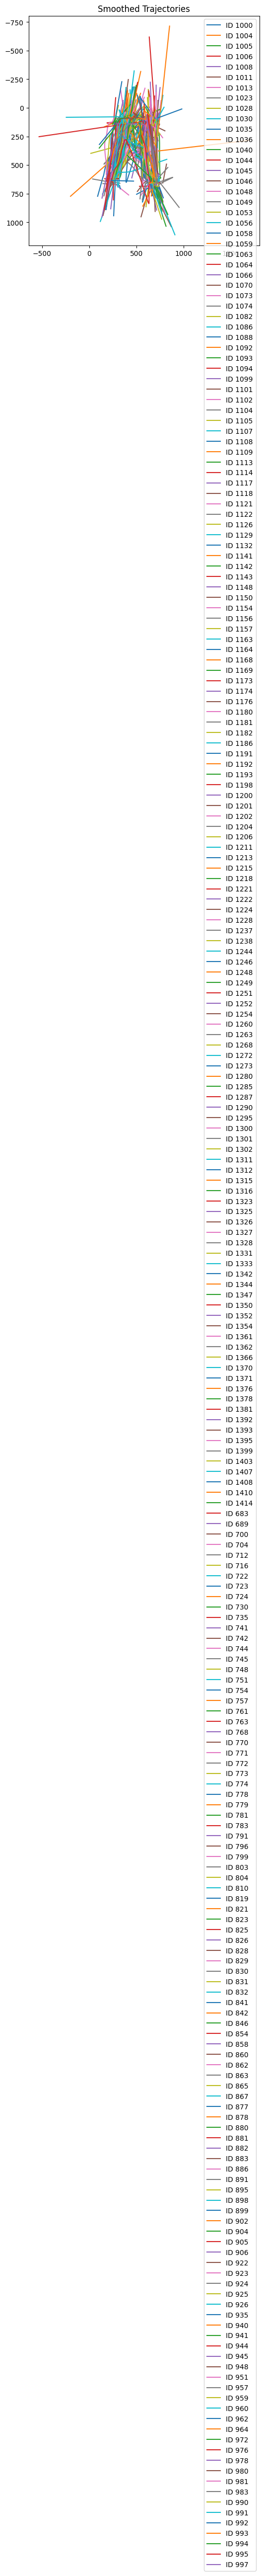

In [ ]:
from scipy.ndimage import gaussian_filter1d

plt.figure(figsize=(6,6))

for track_id, group in df_tracks.groupby('track_id'):
    cx = (group['x1'] + group['x2']) / 2
    cy = (group['y1'] + group['y2']) / 2

    cx_smooth = gaussian_filter1d(cx, sigma=2)
    cy_smooth = gaussian_filter1d(cy, sigma=2)

    plt.plot(cx_smooth, cy_smooth, label=f"ID {track_id}")

plt.gca().invert_yaxis()
plt.legend()
plt.title("Smoothed Trajectories")
plt.show()

In [8]:
# Generate Event Log + People Counting + Directions

import pandas as pd
import numpy as np
import os

tracking_csv = "/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/tracking_results_rgb.csv"

df = pd.read_csv(tracking_csv)

print("Loaded tracking:", df.shape)

# Sort for correct time order
df = df.sort_values(by=["frame", "track_id"]).reset_index(drop=True)

# Compute center of each bbox
df["cx"] = (df["x1"] + df["x2"]) / 2
df["cy"] = (df["y1"] + df["y2"]) / 2


# Define counting line (horizontal line)
# cy = 300
COUNT_LINE_Y = df["cy"].median()   # dynamic line in middle of frame

# Store previous center for each person
prev_y = {}

event_rows = []

total_in = 0
total_out = 0

for idx, row in df.iterrows():

    track_id = row["track_id"]
    frame = row["frame"]
    cy = row["cy"]

    if track_id not in prev_y:
        prev_y[track_id] = cy
        continue

    old_y = prev_y[track_id]
    prev_y[track_id] = cy

    # Person crosses the line?
    crossed = False
    direction = None

    # from TOP → DOWN
    if old_y < COUNT_LINE_Y and cy >= COUNT_LINE_Y:
        crossed = True
        direction = "DOWN"
        total_in += 1

    # from BOTTOM → UP
    elif old_y > COUNT_LINE_Y and cy <= COUNT_LINE_Y:
        crossed = True
        direction = "UP"
        total_out += 1

    if crossed:
        event_rows.append({
            "frame": frame,
            "track_id": track_id,
            "cy_old": old_y,
            "cy_new": cy,
            "direction": direction,
            "event": "CROSS_LINE"
        })

# Convert to DataFrame
df_events = pd.DataFrame(event_rows)

# Save Event Log CSV
event_csv = "/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/event_log_rgb.csv"
df_events.to_csv(event_csv, index=False)

print("--------------------------------------------------")
print("✅ Event logging complete!")
print("📌 Saved event log to:", event_csv)
print("--------------------------------------------------")
print(f"🧍 Total entering (DOWN): {total_in}")
print(f"🚶 Total exiting (UP): {total_out}")
print(f"📈 Total crossings: {len(df_events)}")

Loaded tracking: (14707, 7)
--------------------------------------------------
✅ Event logging complete!
📌 Saved event log to: /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/event_log_rgb.csv
--------------------------------------------------
🧍 Total entering (DOWN): 87
🚶 Total exiting (UP): 90
📈 Total crossings: 177


In [11]:
# Parse XGTF Ground Truth Files → DataFrame / Event Log

import os
import xml.etree.ElementTree as ET
import pandas as pd

# Path to Ground Truth folder
gt_folder = '/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/GROUND TRUTH'

# List all XGTF files
gt_files = [f for f in os.listdir(gt_folder) if f.endswith('.xgtf')]
print("Found GT files:", gt_files)

# Prepare DataFrame
columns = ['file', 'frame', 'person_id', 'x1', 'y1', 'x2', 'y2', 'direction', 'cross_config']
df_gt = pd.DataFrame(columns=columns)

# Loop over files
for gt_file in gt_files:
    file_path = os.path.join(gt_folder, gt_file)
    tree = ET.parse(file_path)
    root = tree.getroot()

    # Namespace handling
    ns = {'v': 'http://lamp.cfar.umd.edu/viper#',
          'data': 'http://lamp.cfar.umd.edu/viperdata#'}

    # Each person object
    for obj in root.findall(".//v:descriptor[@type='OBJECT'][@name='PERSON']", ns):
        person_id = obj.get('id', 'NA')

        # Attributes
        crossing_attr = obj.find(".//v:attribute[@name='Crossing']", ns)
        cross_conf_attr = obj.find(".//v:attribute[@name='Crossing Configuration']", ns)

        direction = crossing_attr.find(".//data:lvalue-enum", ns).get('value') if crossing_attr is not None else None
        cross_config = cross_conf_attr.find(".//data:lvalue-enum", ns).get('value') if cross_conf_attr is not None else None

        # Iterate frames for this person
        for frame in obj.findall(".//v:attribute[@name='BOUNDING_BOX']/data:values/data:frame", ns):
            frame_no = int(frame.get('frameID', -1))
            x1 = float(frame.get('x', 0))
            y1 = float(frame.get('y', 0))
            w = float(frame.get('width', 0))
            h = float(frame.get('height', 0))
            x2 = x1 + w
            y2 = y1 + h

            df_gt.loc[len(df_gt)] = [gt_file, frame_no, person_id, x1, y1, x2, y2, direction, cross_config]

print(f"✅ Parsed {len(df_gt)} bounding boxes from {len(gt_files)} GT files.")

# Save to CSV
output_csv = os.path.join(gt_folder, 'ground_truth_parsed.csv')
df_gt.to_csv(output_csv, index=False)
print("📌 Ground Truth CSV saved at:", output_csv)

Found GT files: ['D_I_S_2.xgtf', 'C_I_S_2.xgtf', 'D_O_S_4.xgtf', 'D_O_G_2.xgtf', 'D_O_G_5.xgtf', 'C_O_S_1.xgtf', 'D_I_S_4.xgtf', 'C_I_G_2.xgtf', 'D_O_S_3.xgtf', 'D_I_S_5.xgtf', 'C_O_G_1.xgtf', 'D_O_S_2.xgtf', 'C_O_G_4.xgtf', 'C_O_S_3.xgtf', 'C_I_S_4.xgtf', 'D_O_G_1.xgtf', 'D_O_S_1.xgtf', 'C_I_S_1.xgtf', 'D_I_S_3.xgtf', 'C_I_S_5.xgtf', 'C_O_G_2.xgtf', 'C_I_S_3.xgtf', 'C_O_S_4.xgtf', 'D_O_G_4.xgtf', 'C_O_S_2.xgtf', 'D_I_G_1.xgtf', 'C_I_G_1.xgtf', 'D_I_G_3.xgtf', 'C_O_G_3.xgtf', 'C_I_G_3.xgtf', 'D_I_G_2.xgtf', 'C_O_G_5.xgtf', 'D_I_S_1.xgtf', 'D_O_G_3.xgtf']
✅ Parsed 0 bounding boxes from 34 GT files.
📌 Ground Truth CSV saved at: /content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/GROUND TRUTH/ground_truth_parsed.csv


In [25]:
# Visualize Counting Line & Person Crossings

import cv2
import os
import pandas as pd

# Paths
frame_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB'
tracking_csv = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/tracking_results_rgb.csv'
output_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/visualized_frames'
os.makedirs(output_folder, exist_ok=True)

# Load tracking data
df_tracks = pd.read_csv(tracking_csv)

# Counting line (horizontal)
count_line_y = 400

# Colors
line_color = (0, 0, 255)      # red
up_color = (0, 255, 0)        # green
down_color = (255, 0, 0)      # blue

# Track previous positions
previous_positions = {}

# Process frames in order
for frame_file in sorted(df_tracks['frame'].unique()):
    frame_path = os.path.join(frame_folder, frame_file)
    img = cv2.imread(frame_path)

    if img is None:
        continue

    frame_data = df_tracks[df_tracks['frame'] == frame_file]

    # Draw counting line
    cv2.line(img, (0, count_line_y), (img.shape[1], count_line_y), line_color, 2)

    # Draw bounding boxes and detect crossings
    for _, row in frame_data.iterrows():
        person_id = row['track_id']
        x1, y1, x2, y2 = int(row['x1']), int(row['y1']), int(row['x2']), int(row['y2'])
        x_center = (x1 + x2) // 2
        y_center = (y1 + y2) // 2

        # Crossing detection
        direction_color = (0, 255, 255)  # default yellow if no crossing
        if person_id in previous_positions:
            prev_y = previous_positions[person_id]
            if prev_y < count_line_y <= y_center:
                direction_color = down_color
            elif prev_y > count_line_y >= y_center:
                direction_color = up_color

        previous_positions[person_id] = y_center

        # Draw bounding box
        cv2.rectangle(img, (x1, y1), (x2, y2), direction_color, 2)
        cv2.putText(img, f"ID:{person_id}", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, direction_color, 2)

    # Save visualized frame
    save_path = os.path.join(output_folder, frame_file)
    cv2.imwrite(save_path, img)

print(f"✅ Visualized frames saved at: {output_folder}")

✅ Visualized frames saved at: /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/visualized_frames


### YOLO Inference on 50% of RGB Frames (Batch-wise)

In [30]:
# Batch-wise YOLO Inference on 50% of RGB Frames
# Save intermediate CSVs for safety

import os
import cv2
import pandas as pd
from ultralytics import YOLO


# Paths & Parameters
rgb_frame_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB'
results_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_batches'
os.makedirs(results_folder, exist_ok=True)

# Load YOLO model (replace with your trained weights if needed)
model = YOLO('yolov8n.pt')

# List all RGB frames
all_frames = sorted([f for f in os.listdir(rgb_frame_folder) if f.endswith('.jpg')])

# Take 50% of frames (from start)
half_index = len(all_frames) // 2
sample_frames = all_frames[:half_index]
total_frames = len(sample_frames)
print(f"Total frames to process (50% of data): {total_frames}")

# Batch Parameters
batch_size = 250
num_batches = (total_frames + batch_size - 1) // batch_size
print(f"Processing in {num_batches} batches of {batch_size} frames")

# Process Each Batch
for batch_idx in range(num_batches):
    start = batch_idx * batch_size
    end = min(start + batch_size, total_frames)
    batch_frames = sample_frames[start:end]

    # Prepare DataFrame for this batch
    columns = ['frame', 'bbox_id', 'x1', 'y1', 'x2', 'y2', 'confidence', 'class_id']
    df_batch = pd.DataFrame(columns=columns)

    for idx, frame_file in enumerate(batch_frames):
        frame_path = os.path.join(rgb_frame_folder, frame_file)
        img = cv2.imread(frame_path)
        if img is None:
            print(f"⚠️ Could not load {frame_file}, skipping.")
            continue

        # Run YOLO inference
        results = model(img, verbose=False)

        # Extract bounding boxes
        for b_id, box in enumerate(results[0].boxes.xyxy):
            x1, y1, x2, y2 = box.tolist()
            conf = results[0].boxes.conf[b_id].item()
            cls = int(results[0].boxes.cls[b_id].item())
            df_batch.loc[len(df_batch)] = [frame_file, b_id, x1, y1, x2, y2, conf, cls]


    # Save intermediate CSV for this batch
    batch_csv = os.path.join(results_folder, f'results_batch_{batch_idx:03d}.csv')
    df_batch.to_csv(batch_csv, index=False)
    print(f"✅ Finished batch {batch_idx+1}/{num_batches}, saved to {batch_csv}")

print("\n🎉 All batches processed for 50% of RGB frames!")

Total frames to process (50% of data): 36475
Processing in 146 batches of 250 frames
✅ Finished batch 1/146, saved to /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_batches/results_batch_000.csv
✅ Finished batch 2/146, saved to /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_batches/results_batch_001.csv
✅ Finished batch 3/146, saved to /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_batches/results_batch_002.csv
✅ Finished batch 4/146, saved to /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_batches/results_batch_003.csv
✅ Finished batch 5/146, saved to /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_batches/results_batch_004.csv
✅ Finished batch 6/146, saved to /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_batches/results_batch_005.csv
✅ Finished batch 7/146, saved to /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_batches/results_batch_006.cs

In [31]:
# Merge All Batch CSVs into a Single Tracking Input CSV

import os
import pandas as pd
import glob

# Path to batch CSVs
results_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_batches'
merged_csv_path = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_detections_rgb_50pct.csv'

# List all batch CSVs
batch_files = sorted(glob.glob(os.path.join(results_folder, 'results_batch_*.csv')))
print(f"Found {len(batch_files)} batch CSV files to merge.")

# Read and concatenate
df_list = []
for f in batch_files:
    df = pd.read_csv(f)
    df_list.append(df)

df_merged = pd.concat(df_list, ignore_index=True)
print(f"Total rows after merge: {len(df_merged)}")

# Save merged CSV
df_merged.to_csv(merged_csv_path, index=False)
print(f"✅ Merged CSV saved at: {merged_csv_path}")

Found 146 batch CSV files to merge.
Total rows after merge: 37691
✅ Merged CSV saved at: /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_detections_rgb_50pct.csv


In [10]:
!pip install deep_sort_realtime

In [12]:
import os
import cv2
import pandas as pd
from deep_sort_realtime.deepsort_tracker import DeepSort

# -------------------------------
# Paths and settings
# -------------------------------
frame_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB'
yolo_csv = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_detections_rgb_50pct.csv'
results_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results'
os.makedirs(results_folder, exist_ok=True)

tracking_csv = os.path.join(results_folder, 'tracking_results_rgb.csv')
event_log_csv = os.path.join(results_folder, 'event_log_rgb_with_timestamp.csv')

FPS = 30  # Frame rate of videos
batch_size = 50  # Adjust based on your memory and speed

# -------------------------------
# Load YOLO detections
# -------------------------------
df_boxes = pd.read_csv(yolo_csv)
df_boxes = df_boxes.sort_values('frame').reset_index(drop=True)
frames = sorted(df_boxes['frame'].unique())

# -------------------------------
# Initialize Tracker
# -------------------------------
tracker = DeepSort(max_age=30)

# -------------------------------
# Load existing tracking CSV if exists
# -------------------------------
if os.path.exists(tracking_csv):
    df_tracks = pd.read_csv(tracking_csv)
    processed_frames = df_tracks['frame'].unique()
    frames = [f for f in frames if f not in processed_frames]
    print(f"Resuming: {len(frames)} frames left.")
else:
    df_tracks = pd.DataFrame(columns=['frame','track_id','x1','y1','x2','y2','confidence'])

# -------------------------------
# Process frames in batches
# -------------------------------
for b in range(0, len(frames), batch_size):
    batch_frames = frames[b:b+batch_size]

    for frame_file in batch_frames:
        frame_path = os.path.join(frame_folder, frame_file)
        img = cv2.imread(frame_path)
        if img is None:
            print(f"⚠️ Could not load {frame_file}")
            continue

        # YOLO detections for this frame
        boxes = df_boxes[df_boxes['frame'] == frame_file]
        detections = []
        for _, row in boxes.iterrows():
            x1, y1, x2, y2 = row[['x1','y1','x2','y2']].astype(float)
            conf = float(row['confidence'])
            cls = 0
            detections.append([(x1, y1, x2, y2), conf, cls])

        # Update tracker
        tracks = tracker.update_tracks(detections, frame=img)
        for t in tracks:
            if not t.is_confirmed():
                continue
            x1, y1, x2, y2 = t.to_ltrb()
            det_conf = t.det_conf if t.det_conf is not None else 0.0
            df_tracks.loc[len(df_tracks)] = [frame_file, t.track_id, x1, y1, x2, y2, det_conf]

    # Save intermediate tracking CSV per batch
    df_tracks.to_csv(tracking_csv, index=False)
    print(f"✅ Finished batch {b//batch_size+1}/{(len(frames)+batch_size-1)//batch_size}")

# -------------------------------
# Generate Event Log with Timestamps
# -------------------------------
df_tracks = df_tracks.sort_values(['frame','track_id']).reset_index(drop=True)
df_tracks['cy'] = (df_tracks['y1'] + df_tracks['y2']) / 2
count_line_y = df_tracks['cy'].median()

prev_y = {}
event_rows = []

for idx, row in df_tracks.iterrows():
    track_id = row['track_id']
    frame_no = int(row['frame'])
    cy = row['cy']

    if track_id not in prev_y:
        prev_y[track_id] = cy
        continue

    old_y = prev_y[track_id]
    prev_y[track_id] = cy

    direction = None
    if old_y < count_line_y <= cy:
        direction = "DOWN"
    elif old_y > count_line_y >= cy:
        direction = "UP"

    if direction is not None:
        timestamp_sec = frame_no / FPS
        event_rows.append({
            "frame_no": frame_no,
            "track_id": track_id,
            "direction": direction,
            "timestamp_sec": timestamp_sec
        })

df_events = pd.DataFrame(event_rows)
df_events.to_csv(event_log_csv, index=False)
print(f"✅ Event Log with timestamps saved at: {event_log_csv}")
print(f"Total crossing events: {len(df_events)}")

Resuming: 4 frames left.
✅ Finished batch 1/1


ValueError: invalid literal for int() with base 10: 'C_I_G_1_frame_00080.jpg'

In [8]:
import pandas as pd
import re

# Paths
event_log_csv = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/event_log_rgb_with_timestamp.csv'
FPS = 30  # Frame rate of videos

# -------------------------------
# Extract numeric frame number from file names
# -------------------------------
def extract_frame_number(filename):
    m = re.search(r'(\d+)\.jpg$', filename)
    if m:
        return int(m.group(1))
    else:
        return None

df_tracks['frame_no'] = df_tracks['frame'].apply(extract_frame_number)

# -------------------------------
# Compute center of bounding boxes
# -------------------------------
df_tracks['cy'] = (df_tracks['y1'] + df_tracks['y2']) / 2
count_line_y = df_tracks['cy'].median()

# -------------------------------
# Generate Event Log with direction & timestamp
# -------------------------------
prev_y = {}
event_rows = []

for idx, row in df_tracks.iterrows():
    track_id = row['track_id']
    frame_no = row['frame_no']
    cy = row['cy']

    if track_id not in prev_y:
        prev_y[track_id] = cy
        continue

    old_y = prev_y[track_id]
    prev_y[track_id] = cy

    direction = None
    if old_y < count_line_y <= cy:
        direction = "DOWN"
    elif old_y > count_line_y >= cy:
        direction = "UP"

    if direction is not None:
        timestamp_sec = frame_no / FPS
        event_rows.append({
            "timestamp_sec": timestamp_sec,
            "frame_no": frame_no,
            "track_id": track_id,
            "direction": direction
        })

df_events = pd.DataFrame(event_rows)

# Save CSV
df_events.to_csv(event_log_csv, index=False)
print(f"✅ Event Log with timestamps saved at: {event_log_csv}")
print(f"Total crossing events: {len(df_events)}")

✅ Event Log with timestamps saved at: /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/event_log_rgb_with_timestamp.csv
Total crossing events: 1087


In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.1 MB/s eta 0:00:00


In [7]:
import os
import cv2
import pandas as pd
from ultralytics import YOLO

# Paths & Parameters
depth_frame_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/DEPTH'
results_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_batches_depth'
os.makedirs(results_folder, exist_ok=True)

# Load YOLO model (replace with your trained weights if needed)
model = YOLO('yolov8n.pt')

# List all Depth frames
all_frames = sorted([f for f in os.listdir(depth_frame_folder) if f.endswith('.jpg') or f.endswith('.png')])

# Take 50% of frames (from start)
half_index = len(all_frames) // 2
sample_frames = all_frames[:half_index]
total_frames = len(sample_frames)
print(f"Total frames to process (50% of data): {total_frames}")

# Batch Parameters
batch_size = 250
num_batches = (total_frames + batch_size - 1) // batch_size
print(f"Processing in {num_batches} batches of {batch_size} frames")

# Process Each Batch
for batch_idx in range(num_batches):
    start = batch_idx * batch_size
    end = min(start + batch_size, total_frames)
    batch_frames = sample_frames[start:end]

    # Prepare DataFrame for this batch
    columns = ['frame', 'bbox_id', 'x1', 'y1', 'x2', 'y2', 'confidence', 'class_id']
    df_batch = pd.DataFrame(columns=columns)

    for idx, frame_file in enumerate(batch_frames):
        frame_path = os.path.join(depth_frame_folder, frame_file)
        img = cv2.imread(frame_path)
        if img is None:
            print(f"⚠️ Could not load {frame_file}, skipping.")
            continue

        # Run YOLO inference
        results = model(img, verbose=False)

        # Extract bounding boxes
        for b_id, box in enumerate(results[0].boxes.xyxy):
            x1, y1, x2, y2 = box.tolist()
            conf = results[0].boxes.conf[b_id].item()
            cls = int(results[0].boxes.cls[b_id].item())
            df_batch.loc[len(df_batch)] = [frame_file, b_id, x1, y1, x2, y2, conf, cls]

    # Save intermediate CSV for this batch
    batch_csv = os.path.join(results_folder, f'results_batch_{batch_idx:03d}.csv')
    df_batch.to_csv(batch_csv, index=False)
    print(f"✅ Finished batch {batch_idx+1}/{num_batches}, saved to {batch_csv}")

print("\n🎉 All batches processed for 50% of Depth frames!")

Total frames to process (50% of data): 17781
Processing in 72 batches of 250 frames


KeyboardInterrupt: 

In [9]:
import os
import pandas as pd

# -------------------------------
# Paths
# -------------------------------
rgb_frame_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB'
depth_frame_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/DEPTH'
results_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_batches_depth'
os.makedirs(results_folder, exist_ok=True)

# -------------------------------
# Load RGB frames (the 50% you already chose)
# -------------------------------
rgb_csv = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_detections_rgb_50pct.csv'
df_rgb = pd.read_csv(rgb_csv)
rgb_frames_used = sorted(df_rgb['frame'].unique())  # exact frames you processed

# -------------------------------
# List all Depth frames
# -------------------------------
all_depth_frames = sorted([f for f in os.listdir(depth_frame_folder) if f.endswith('.png') or f.endswith('.jpg')])

# -------------------------------
# Select only Depth frames corresponding to RGB frames
# -------------------------------
# Assumption: Depth frame names match RGB frame numbers, e.g.,
# RGB: C_I_G_1_frame_00001.jpg  <-> Depth: C_I_G_1_depth_00001.png
# We'll extract the frame index from RGB filenames and match
selected_depth_frames = []
for rgb_fname in rgb_frames_used:
    frame_number = rgb_fname.split('_')[-1].split('.')[0]  # '00001'
    # Find matching Depth file
    for depth_fname in all_depth_frames:
        if frame_number in depth_fname:
            selected_depth_frames.append(depth_fname)
            break

print(f"Total selected Depth frames matching RGB: {len(selected_depth_frames)}")

# -------------------------------
# Optional: save list to CSV for batch processing
# -------------------------------
depth_list_csv = os.path.join(results_folder, 'depth_frames_50pct.csv')
pd.DataFrame({'frame': selected_depth_frames}).to_csv(depth_list_csv, index=False)
print(f"✅ Depth frame list saved at: {depth_list_csv}")

Total selected Depth frames matching RGB: 24019
✅ Depth frame list saved at: /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_batches_depth/depth_frames_50pct.csv


In [15]:
import os
import cv2
import pandas as pd
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort

# -------------------------------
# Paths & Parameters
# -------------------------------
depth_frame_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/DEPTH'
results_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/depth_batches'
os.makedirs(results_folder, exist_ok=True)

yolo_model_path = 'yolov8n.pt'  # replace with your model if needed
FPS = 30  # fps of videos
batch_size = 250  # adjust based on memory

# Output CSV paths
tracking_csv = os.path.join(results_folder, 'tracking_results_depth.csv')
event_log_csv = os.path.join(results_folder, 'event_log_depth_with_timestamp.csv')

# -------------------------------
# Load YOLO model
# -------------------------------
model = YOLO(yolo_model_path)

# -------------------------------
# List Depth frames
# -------------------------------
all_frames = sorted([f for f in os.listdir(depth_frame_folder) if f.endswith('.jpg')])
half_index = len(all_frames) // 2
sample_frames = all_frames[:half_index]  # 50% consecutive frames
total_frames = len(sample_frames)
num_batches = (total_frames + batch_size - 1) // batch_size
print(f"Total Depth frames: {total_frames}, in {num_batches} batches")

# -------------------------------
# Initialize Tracker
# -------------------------------
tracker = DeepSort(max_age=30)

# -------------------------------
# Load existing tracking CSV if exists
# -------------------------------
if os.path.exists(tracking_csv):
    df_tracks = pd.read_csv(tracking_csv)
    processed_frames = df_tracks['frame'].unique()
    sample_frames = [f for f in sample_frames if f not in processed_frames]
    print(f"Resuming: {len(sample_frames)} frames left")
else:
    df_tracks = pd.DataFrame(columns=['frame','track_id','x1','y1','x2','y2','confidence'])

# -------------------------------
# Process batches
# -------------------------------
for batch_idx in range(num_batches):
    start = batch_idx * batch_size
    end = min(start + batch_size, total_frames)
    batch_frames = sample_frames[start:end]

    df_batch = pd.DataFrame(columns=['frame','bbox_id','x1','y1','x2','y2','confidence','class_id'])

    for frame_file in batch_frames:
        frame_path = os.path.join(depth_frame_folder, frame_file)
        img = cv2.imread(frame_path)
        if img is None:
            print(f"⚠️ Could not load {frame_file}")
            continue

        # YOLO inference
        results = model(img, verbose=False)

        for b_id, box in enumerate(results[0].boxes.xyxy):
            x1, y1, x2, y2 = box.tolist()
            conf = results[0].boxes.conf[b_id].item()
            cls = int(results[0].boxes.cls[b_id].item())
            df_batch.loc[len(df_batch)] = [frame_file, b_id, x1, y1, x2, y2, conf, cls]

        # Update Tracker
        detections = [[(row['x1'], row['y1'], row['x2'], row['y2']), row['confidence'], 0]
                      for idx,row in df_batch[df_batch['frame']==frame_file].iterrows()]

        tracks = tracker.update_tracks(detections, frame=img)
        for t in tracks:
            if not t.is_confirmed():
                continue
            x1, y1, x2, y2 = t.to_ltrb()
            det_conf = t.det_conf if t.det_conf is not None else 0.0
            df_tracks.loc[len(df_tracks)] = [frame_file, t.track_id, x1, y1, x2, y2, det_conf]

    # Save intermediate tracking CSV per batch
    df_tracks.to_csv(tracking_csv, index=False)
    print(f"✅ Finished batch {batch_idx+1}/{num_batches}, saved tracking CSV")

# -------------------------------
# Generate Event Log with Timestamps
# -------------------------------
df_tracks = df_tracks.sort_values(['frame','track_id']).reset_index(drop=True)
df_tracks['cy'] = (df_tracks['y1'] + df_tracks['y2']) / 2
count_line_y = df_tracks['cy'].median()

prev_y = {}
event_rows = []

for idx, row in df_tracks.iterrows():
    track_id = row['track_id']
    frame_no = int(row['frame'].split('_')[-1].split('.')[0])  # extract frame number
    cy = row['cy']

    if track_id not in prev_y:
        prev_y[track_id] = cy
        continue

    old_y = prev_y[track_id]
    prev_y[track_id] = cy

    direction = None
    if old_y < count_line_y <= cy:
        direction = "DOWN"
    elif old_y > count_line_y >= cy:
        direction = "UP"

    if direction is not None:
        timestamp_sec = frame_no / FPS
        event_rows.append({
            "frame_no": frame_no,
            "track_id": track_id,
            "direction": direction,
            "timestamp_sec": timestamp_sec
        })

df_events = pd.DataFrame(event_rows)
df_events.to_csv(event_log_csv, index=False)
print(f"✅ Depth Event Log with timestamps saved at: {event_log_csv}")
print(f"Total crossing events: {len(df_events)}")

Total Depth frames: 17781, in 72 batches
✅ Finished batch 1/72, saved tracking CSV
✅ Finished batch 2/72, saved tracking CSV
✅ Finished batch 3/72, saved tracking CSV
✅ Finished batch 4/72, saved tracking CSV
✅ Finished batch 5/72, saved tracking CSV
✅ Finished batch 6/72, saved tracking CSV
✅ Finished batch 7/72, saved tracking CSV
✅ Finished batch 8/72, saved tracking CSV
✅ Finished batch 9/72, saved tracking CSV
✅ Finished batch 10/72, saved tracking CSV
✅ Finished batch 11/72, saved tracking CSV
✅ Finished batch 12/72, saved tracking CSV
✅ Finished batch 13/72, saved tracking CSV
✅ Finished batch 14/72, saved tracking CSV
✅ Finished batch 15/72, saved tracking CSV
✅ Finished batch 16/72, saved tracking CSV
✅ Finished batch 17/72, saved tracking CSV
✅ Finished batch 18/72, saved tracking CSV
✅ Finished batch 19/72, saved tracking CSV
✅ Finished batch 20/72, saved tracking CSV
✅ Finished batch 21/72, saved tracking CSV
✅ Finished batch 22/72, saved tracking CSV
✅ Finished batch 23/72

In [1]:
!pip install deep_sort_realtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 37.2 MB/s eta 0:00:00


In [9]:
import os
import cv2
import pandas as pd
from deep_sort_realtime.deepsort_tracker import DeepSort
from ultralytics import YOLO

# -------------------------------
# Paths & Parameters
# -------------------------------
depth_frame_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/DEPTH'
results_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/depth_batches'
os.makedirs(results_folder, exist_ok=True)

# YOLO model
model = YOLO('yolov8n.pt')
tracker = DeepSort(max_age=30)

FPS = 30
batch_size = 250

# -------------------------------
# List all Depth frames
# -------------------------------
all_frames = sorted([f for f in os.listdir(depth_frame_folder) if f.endswith('.jpg') or f.endswith('.png')])
total_frames = len(all_frames)
num_batches = (total_frames + batch_size - 1) // batch_size
print(f"Total depth frames: {total_frames}, processing in {num_batches} batches of {batch_size}")

# DataFrame for Event Log
columns = ['frame', 'person_id', 'direction', 'timestamp']
df_final_events = pd.DataFrame(columns=columns)

# -------------------------------
# Batch-wise YOLO + Tracking + Event Log
# -------------------------------
for batch_idx in range(num_batches):
    start = batch_idx * batch_size
    end = min(start + batch_size, total_frames)
    batch_frames = all_frames[start:end]

    df_tracks = pd.DataFrame(columns=['frame','track_id','x1','y1','x2','y2','confidence'])

    for frame_file in batch_frames:
        frame_path = os.path.join(depth_frame_folder, frame_file)
        img = cv2.imread(frame_path)
        if img is None:
            print(f"⚠️ Could not load {frame_file}")
            continue

        # YOLO detection
        results = model(img, conf=0.5, verbose=False)
        detections = []
        for i, box in enumerate(results[0].boxes.xyxy):
            x1, y1, x2, y2 = box.tolist()
            conf = results[0].boxes.conf[i].item()
            cls = int(results[0].boxes.cls[i].item())
            detections.append([(x1, y1, x2, y2), conf, cls])

        # Update tracker
        tracks = tracker.update_tracks(detections, frame=img)
        for t in tracks:
            if not t.is_confirmed():
                continue
            x1, y1, x2, y2 = t.to_ltrb()
            det_conf = t.det_conf if t.det_conf is not None else 0.0
            df_tracks.loc[len(df_tracks)] = [frame_file, t.track_id, x1, y1, x2, y2, det_conf]

    # Event Log for batch
    df_tracks = df_tracks.sort_values(['frame','track_id']).reset_index(drop=True)
    df_tracks['cy'] = (df_tracks['y1'] + df_tracks['y2']) / 2
    count_line_y = df_tracks['cy'].median()
    prev_y = {}

    for idx, row in df_tracks.iterrows():
        track_id = row['track_id']
        frame_no = row['frame']
        cy = row['cy']

        if track_id not in prev_y:
            prev_y[track_id] = cy
            continue

        old_y = prev_y[track_id]
        prev_y[track_id] = cy

        direction = None
        if old_y < count_line_y <= cy:
            direction = "DOWN"
        elif old_y > count_line_y >= cy:
            direction = "UP"

        if direction is not None:
            timestamp = int(frame_no.split('_')[-1].split('.')[0]) / FPS  # از شماره فریم
            df_final_events.loc[len(df_final_events)] = [frame_no, track_id, direction, timestamp]

    # Save intermediate CSV per batch
    batch_csv = os.path.join(results_folder, f'event_log_depth_batch_{batch_idx:03d}.csv')
    df_final_events.to_csv(batch_csv, index=False)
    print(f"✅ Finished batch {batch_idx+1}/{num_batches}, saved {batch_csv}")

# Save final Event Log
final_csv = os.path.join(results_folder, 'event_log_depth_simple.csv')
df_final_events.to_csv(final_csv, index=False)
print(f"🎉 All Depth frames processed. Final simplified Event Log saved at: {final_csv}")

Total depth frames: 35563, processing in 143 batches of 250
✅ Finished batch 1/143, saved /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/depth_batches/event_log_depth_batch_000.csv
✅ Finished batch 2/143, saved /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/depth_batches/event_log_depth_batch_001.csv
✅ Finished batch 3/143, saved /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/depth_batches/event_log_depth_batch_002.csv
✅ Finished batch 4/143, saved /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/depth_batches/event_log_depth_batch_003.csv
✅ Finished batch 5/143, saved /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/depth_batches/event_log_depth_batch_004.csv
✅ Finished batch 6/143, saved /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/depth_batches/event_log_depth_batch_005.csv
✅ Finished batch 7/143, saved /content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/depth_batches/event_log_d

In [7]:
!fusermount -u /content/drive

In [8]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive
